In [1]:
import numpy as np
from sklearn.feature_selection import f_regression
import statsmodels.api as sm


In [2]:
npz = np.load('./Data/Audiobooks_data_train.npz')
train_inputs = npz['inputs'].astype(float)
train_targets = npz['outputs'].astype(int)

npz = np.load('./Data/Audiobooks_data_validation.npz')
validation_inputs = npz['inputs'].astype(float)
validation_targets = npz['outputs'].astype(int)

npz = np.load('./Data/Audiobooks_data_test.npz')
test_inputs = npz['inputs'].astype(float)
test_targets = npz['outputs'].astype(int)

In [3]:
train_inputs.shape

(3131, 6)

In [4]:
print(np.mean(train_inputs, axis=0))
print(np.std(train_inputs, axis=0))

[ 0.00054082  0.00163502 -0.01225021  0.00767923  0.00549712  0.00598346]
[1.00490515 1.0055262  0.92946525 1.01108226 0.99896845 1.0013534 ]


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')
model.fit(train_inputs, train_targets)
print(model.score(train_inputs, train_targets))



0.801980198019802


In [6]:
# from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# # y_prob_train = model.predict_proba(train_inputs)[:,1]
# # y_pred_train = (y_prob_tran >= 0.5).astype(int)
# # y_prob_validation = model.predict_proba(validation_inputs)[:,1]
# # y_pred_validation = (y_prob_validation >= 0.5).astype(int)
# y_prob_test = model.predict_proba(test_inputs)[:,1]
# y_pred_test = (y_prob_test >= 0.6).astype(int)


# cm = confusion_matrix(test_targets, y_pred_test)
# accuracy = accuracy_score(test_targets, y_pred_test)
# precision = precision_score(test_targets, y_pred_test)
# recall = recall_score(test_targets, y_pred_test)
# f1 = f1_score(test_targets, y_pred_test)

# print("Confusion Matrix:\n", cm)
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)


In [7]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Logistic Regression probabilities for class 1 = purchase
y_prob_train = model.predict_proba(train_inputs)[:, 1]
y_prob_val = model.predict_proba(validation_inputs)[:, 1]
y_prob_test = model.predict_proba(test_inputs)[:, 1]

# Classification labels using chosen threshold
threshold = 0.7
y_pred_train = (y_prob_train >= threshold).astype(int)
y_pred_val = (y_prob_val >= threshold).astype(int)
y_pred_test = (y_prob_test >= threshold).astype(int)

# Final model evaluation should be reported on the test set only
cm = confusion_matrix(test_targets, y_pred_test)
accuracy = accuracy_score(test_targets, y_pred_test)
precision = precision_score(test_targets, y_pred_test)
recall = recall_score(test_targets, y_pred_test)
f1 = f1_score(test_targets, y_pred_test)

print("Confusion Matrix:", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix: [[341  18]
 [152 160]]
Accuracy: 0.7466467958271237
Precision: 0.898876404494382
Recall: 0.5128205128205128
F1 Score: 0.6530612244897959


In [8]:
import pandas as pd

df = pd.DataFrame({
    'y_true': test_targets,
    'y_score': y_prob_test
})

df = df.sort_values(by='y_score', ascending=False).reset_index(drop=True)

In [9]:

baseline = df['y_true'].mean() #out of all the users how many actually bought

def precision_at_k(df, k):
    cutoff = int(len(df) * k)
    top_k = df.iloc[:cutoff]
    return top_k['y_true'].mean()
k = 0.1
precision_topX = {}
lift = {}
for k in [0.1,0.2,0.3,0.4,0.5]:
    precision_topX[k] = precision_at_k(df, k)
    lift[k] = precision_topX[k]/baseline
    
    print(f"Baseline conversion rate: {baseline:0.2f} ({baseline*100:0.2f}%)")
    print(f"Precision@{k*100.0:0.0f}%: {precision_topX[k]:0.2f} ({precision_topX[k]*100:0.2f}%)")
    
    print(f"Lift@{k*100.0:0.0f}%: {lift[k]:.2f}x")    
    print(f"If baseline conversion = {baseline*100:0.2f}% then Precision@{k*100:0.0f}% = {precision_topX[k]*100:0.2f}%")
    print(f"If I target top {k*100}% users, {precision_topX[k]*100:0.2f}% may actually convert.")
    print(f"Those top {k*100}% users are {lift[k]:0.2f}x more likely to convert than a random test-set user.")


Baseline conversion rate: 0.46 (46.50%)
Precision@10%: 1.00 (100.00%)
Lift@10%: 2.15x
If baseline conversion = 46.50% then Precision@10% = 100.00%
If I target top 10.0% users, 100.00% may actually convert.
Those top 10.0% users are 2.15x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@20%: 0.95 (94.78%)
Lift@20%: 2.04x
If baseline conversion = 46.50% then Precision@20% = 94.78%
If I target top 20.0% users, 94.78% may actually convert.
Those top 20.0% users are 2.04x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@30%: 0.88 (87.56%)
Lift@30%: 1.88x
If baseline conversion = 46.50% then Precision@30% = 87.56%
If I target top 30.0% users, 87.56% may actually convert.
Those top 30.0% users are 1.88x more likely to convert than a random test-set user.
Baseline conversion rate: 0.46 (46.50%)
Precision@40%: 0.84 (83.96%)
Lift@40%: 1.81x
If baseline conversion = 46.50% then Precision@40% 

In [10]:
# # user-level export
# user_export = pd.DataFrame({
#     'model': 'Logistic Regression',
#     'y_true': test_targets,
#     'y_score': y_prob_test,
#     'y_pred': y_pred_test
# })
# user_export.to_csv('logistic_user_predictions.csv', index=False)

# # metric export
# metrics_export = pd.DataFrame({
#     'model': ['Logistic Regression'],
#     'accuracy': [accuracy],
#     'recall': [recall],
#     'f1': [f1],
#     'baseline_conversion_at': [baseline*100.0],
#     'true_neg': [cm[0, 0]],
#     'false_pos': [cm[0, 1]],
#     'false_neg': [cm[1, 0]],
#     'true_pos': [cm[1, 1]]
# })
# for k in precision:
#     metrics_export[f'precision @{k*100}%']= precision[k]
#     metrics_export[f'lift @{k*100}%']= lift[k]

# metrics_export.to_csv('logistic_model_metrics.csv', index=False)

In [11]:
# user-level export
user_export = pd.DataFrame({
    'model': 'Logistic Regression',
    'y_true': test_targets,
    'y_score': y_prob_test,
    'y_pred': y_pred_test
})
user_export.to_csv('./Data/logistic_user_predictions.csv', index=False)

# metric export
metrics_export = pd.DataFrame({
    'metric': ['accuracy','precision', 'recall', 'f1', 'baseline_conversion_at', 'true_neg', 'false_pos', 'false_neg', 'true_pos'],
    'Logistic Regression':[accuracy, precision, recall, f1, baseline*100.0, cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]]
})

# add precision and lift as rows
for k in precision_topX:
    new_rows = pd.DataFrame({
        'metric': [
            f'precision_at_{int(k*100)}%',
            f'lift_at_{int(k*100)}%'
        ],
        'Logistic Regression': [
            precision_topX[k],
            lift[k]
        ]
    })

    metrics_export = pd.concat([metrics_export, new_rows], ignore_index=True)

print(metrics_export)
metrics_export.to_csv('./Data/logistic_model_metrics.csv', index=False)

                    metric  Logistic Regression
0                 accuracy             0.746647
1                precision             0.898876
2                   recall             0.512821
3                       f1             0.653061
4   baseline_conversion_at            46.497765
5                 true_neg           341.000000
6                false_pos            18.000000
7                false_neg           152.000000
8                 true_pos           160.000000
9         precision_at_10%             1.000000
10             lift_at_10%             2.150641
11        precision_at_20%             0.947761
12             lift_at_20%             2.038294
13        precision_at_30%             0.875622
14             lift_at_30%             1.883148
15        precision_at_40%             0.839552
16             lift_at_40%             1.805575
17        precision_at_50%             0.761194
18             lift_at_50%             1.637055


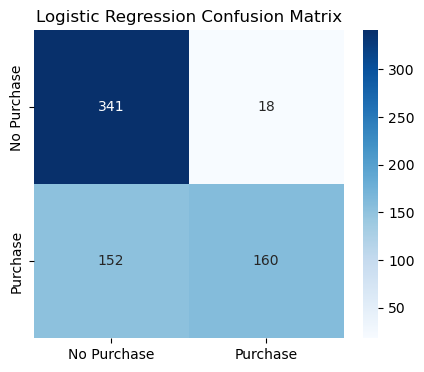

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)
plt.title('Logistic Regression Confusion Matrix')
plt.savefig('ls_cm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()